## 1. Setup

### 1.1 Importar Libs

In [1]:
# Importação das bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import os
import json
import pickle
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import (classification_report, confusion_matrix, 
                           accuracy_score, precision_score, recall_score, 
                           f1_score, roc_auc_score, roc_curve)
from sklearn.preprocessing import StandardScaler
from scipy.stats import uniform, randint
from joblib import dump, load
import warnings
warnings.filterwarnings('ignore')

# Importar funções dos módulos customizados
from ml_utils import evaluate_model, load_and_prepare_datasets, SCORING_METRIC
from search_utils import (plot_search_history, multiple_randomized_search,
                          plot_search_history_from_loaded, 
                          load_search_results, get_best_params_from_saved,
                          save_search_results, save_final_results, 
                          DEFAULT_CV_STRATEGY, SEARCHES_FOLDER, RESULTS_FOLDER, MODELS_FOLDER)

from manual_implement_models import NeuralNetworkCommittee

# Configurações de plotagem
plt.rcParams['figure.figsize'] = [12, 8]
sns.set_style("whitegrid")

print("Bibliotecas importadas com sucesso!")
print(f"Pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Scikit-learn: {sklearn.__version__}")

Bibliotecas importadas com sucesso!
Pandas: 2.2.3
NumPy: 2.0.2
Scikit-learn: 1.6.1


### 1.2 Configuração do Modelo

In [2]:
# Configuração do modelo e hiperparâmetros
MODEL_NAME = "NeuralCommittee"
MODEL_CLASS = NeuralNetworkCommittee
RANDOM_STATE_MODEL = 42
RANDOM_STATE_SAMPLE = 10

# Configuração da busca de hiperparâmetros
N_SEARCHES = 20
N_ITER_PER_SEARCH = 5
SAMPLE_SIZE = 0.05  # % of training data for hyperparameter search


print(f"Modelo configurado: {MODEL_NAME}")
print(f"Buscas: {N_SEARCHES} x {N_ITER_PER_SEARCH} iterações")

Modelo configurado: NeuralCommittee
Buscas: 20 x 5 iterações


## 2. Carregamento e Preparação dos Dados

In [3]:
# Carregamento e preparação inicial dos dados
print("=== CARREGAMENTO DOS DATASETS ===")

# Carregar e preparar datasets usando função do módulo
X_train, X_test, y_train, y_test, X_train_scaled, X_test_scaled, train_data, test_data, scaler = load_and_prepare_datasets()

print(f"Dataset de treino: {train_data.shape}")
print(f"Dataset de teste: {test_data.shape}")
print(f"Features: {X_train_scaled.shape[1]}")

print("\nDistribuição das classes:")
print("Treino:", y_train.value_counts().to_dict())
print("Teste:", y_test.value_counts().to_dict())

print("\nPrimeiras linhas do dataset de treino:")

=== CARREGAMENTO DOS DATASETS ===
Dataset de treino: (37233, 1825)
Dataset de teste: (12411, 1825)
Features: 1824

Distribuição das classes:
Treino: {1: 7050, 2: 5577, 3: 4282, 4: 3733, 5: 3430, 7: 2895, 6: 2857, 8: 2537, 0: 2533, 9: 2339}
Teste: {1: 2430, 2: 1790, 3: 1408, 4: 1257, 5: 1203, 6: 995, 7: 912, 8: 815, 0: 813, 9: 788}

Primeiras linhas do dataset de treino:


In [4]:
train_data.head()

,0,1,2,3,4,5,6,7,8,9,...,1815,1816,1817,1818,1819,1820,1821,1822,1823,digit
0,0.132290,-0.078874,-0.007970,0.126206,-0.019496,0.049232,0.118899,-0.035883,0.027992,0.031445,...,1.514577,1.355709,1.418220,1.314246,1.393841,1.382280,1.272189,1.350409,1.342505,1
1,-1.261489,-1.223371,-1.000089,-1.225078,-1.232434,-0.959512,-1.124728,-1.226982,-0.848620,-1.207445,...,-1.251411,-1.451988,-1.167611,-1.313675,-1.466612,-1.229501,-1.268458,-1.301135,-1.067532,1
2,-0.803139,-0.742865,-0.624391,-0.887569,-0.834537,-0.721469,-0.968023,-0.922214,-0.717852,-0.951887,...,-1.567787,-1.773163,-1.590253,-1.399433,-1.590376,-1.392650,-1.309864,-1.443503,-1.416043,1
3,0.495477,0.708491,0.804662,0.502907,0.720904,0.816273,0.587815,0.800239,0.893713,0.593013,...,0.951751,0.926661,1.139622,0.921222,0.899732,1.112191,0.930080,0.907232,1.048508,2
4,0.731854,0.843948,0.588933,0.628960,0.746698,0.552313,0.452046,0.575681,0.506712,0.329009,...,0.918366,0.802927,0.817431,0.947489,0.807747,0.683944,0.860839,0.730585,0.559723,2


## 3. Sampling para Busca de Hiperparâmetros

In [5]:
# ======================================================================
# SAMPLING ESTRATIFICADO PARA BUSCA DE HIPERPARÂMETROS
# ======================================================================

print("=== PREPARAÇÃO DE AMOSTRA PARA BUSCA DE HIPERPARÂMETROS ===")

# Amostra estratificada do dataset de treino
_, X_sample, _, y_sample = train_test_split(
    X_train_scaled, y_train, 
    test_size=SAMPLE_SIZE,  
    stratify=y_train,
    random_state=RANDOM_STATE_SAMPLE
)

print(f"Dataset original de treino: {X_train_scaled.shape[0]:,} amostras")
print(f"Amostra para busca de hiperparâmetros: {X_sample.shape[0]:,} amostras")
print(f"Redução: {(1 - X_sample.shape[0]/X_train_scaled.shape[0])*100:.1f}%")

print("\nDistribuição das classes na amostra:")
print("Amostra:", pd.Series(y_sample).value_counts().to_dict())
print("Original:", y_train.value_counts().to_dict())

=== PREPARAÇÃO DE AMOSTRA PARA BUSCA DE HIPERPARÂMETROS ===
Dataset original de treino: 37,233 amostras
Amostra para busca de hiperparâmetros: 1,862 amostras
Redução: 95.0%

Distribuição das classes na amostra:
Amostra: {1: 352, 2: 279, 3: 214, 4: 187, 5: 171, 7: 145, 6: 143, 0: 127, 8: 127, 9: 117}
Original: {1: 7050, 2: 5577, 3: 4282, 4: 3733, 5: 3430, 7: 2895, 6: 2857, 8: 2537, 0: 2533, 9: 2339}


## 4. Definir Estratégia de Validação Cruzada

In [6]:
# Usar estratégia de CV padrão dos módulos
print(f"Estratégia de CV: {DEFAULT_CV_STRATEGY}")

Estratégia de CV: StratifiedKFold(n_splits=5, random_state=42, shuffle=True)


## 5. Neural Committee - Busca de Hiperparâmetros


### 5.1 Definir Espaço de Hiperparâmetros


In [7]:
# ======================================================================
# DEFINIÇÃO DO ESPAÇO DE HIPERPARÂMETROS - COMITÊ DE REDES NEURAIS
# ======================================================================

print(f"=== DEFINIÇÃO DO ESPAÇO DE HIPERPARÂMETROS — {MODEL_NAME} ===")

from scipy.stats import loguniform, randint

# ----------------------------------------------------------------------
# GRUPOS DE ARQUITETURAS OTIMIZADAS
# ----------------------------------------------------------------------

# Grupo A — Redes grandes
large_architectures = [
    (1024, 256, 128),
    (1024, 384, 128),
    (768, 256, 128),
    (512, 256, 128),
    (1024, 256),
    (768, 256),
]

# Grupo B — Redes médias
medium_architectures = [
    (256, 128, 64),
    (256, 128),
    (128, 64),
    (256,),
    (128,),
]

# Grupo C — Redes pequenas
small_architectures = [
    (100, 50, 25),
    (100, 50),
    (50, 25),
    (50,),
]


# ======================================================================
# DISTRIBUIÇÕES GERAIS (OTIMIZADAS)
# ======================================================================

# Log-uniform conforme boas práticas (como na MLP individual)
alpha_dist = loguniform(1e-5, 1e-1)
learning_rate_init_dist = loguniform(1e-4, 1e-1)

# Aumentado para convergência mais confiável no comitê
max_iter_dist = randint(500, 1500)

# Opções compartilhadas
activation_options = ['relu', 'tanh', 'logistic']
learning_rate_options = ['constant', 'adaptive']
solver_large = ['adam', 'sgd']    
solver_medium = ['adam', 'sgd', 'lbfgs']
solver_small = ['adam', 'lbfgs']    


# ======================================================================
# PARAM_DISTRIBUTIONS — 3 REDES COM PERSONALIDADES DIFERENTES
# ======================================================================

param_distributions = {

    # ----------------------------------------------------------
    # === MLP 1 — Rede GRANDE ===
    # ----------------------------------------------------------
    'mlp1_hidden_layers': large_architectures,
    'mlp1_alpha': alpha_dist,
    'mlp1_learning_rate_init': learning_rate_init_dist,
    'mlp1_max_iter': max_iter_dist,
    'mlp1_activation': activation_options,
    'mlp1_learning_rate': learning_rate_options,
    'mlp1_solver': solver_large,

    # ----------------------------------------------------------
    # === MLP 2 — Rede MÉDIA ===
    # ----------------------------------------------------------
    'mlp2_hidden_layers': medium_architectures,
    'mlp2_alpha': alpha_dist,
    'mlp2_learning_rate_init': learning_rate_init_dist,
    'mlp2_max_iter': max_iter_dist,
    'mlp2_activation': activation_options,
    'mlp2_learning_rate': learning_rate_options,
    'mlp2_solver': solver_medium,

    # ----------------------------------------------------------
    # === MLP 3 — Rede PEQUENA ===
    # ----------------------------------------------------------
    'mlp3_hidden_layers': small_architectures,
    'mlp3_alpha': alpha_dist,
    'mlp3_learning_rate_init': learning_rate_init_dist,
    'mlp3_max_iter': max_iter_dist,
    'mlp3_activation': activation_options,
    'mlp3_learning_rate': learning_rate_options,
    'mlp3_solver': solver_small,
}

print("\n=== ESPAÇO DE HIPERPARÂMETROS DEFINIDO (OTIMIZADO) ===")
print("Comitê com 3 redes distintas:")
print("  - MLP 1: grandes arquiteturas (alta capacidade)")
print("  - MLP 2: arquiteturas médias (equilíbrio)")
print("  - MLP 3: arquiteturas pequenas (alta estabilidade)")
print(f"Total de arquiteturas: {len(large_architectures) + len(medium_architectures) + len(small_architectures)}")


=== DEFINIÇÃO DO ESPAÇO DE HIPERPARÂMETROS — NeuralCommittee ===

=== ESPAÇO DE HIPERPARÂMETROS DEFINIDO (OTIMIZADO) ===
Comitê com 3 redes distintas:
  - MLP 1: grandes arquiteturas (alta capacidade)
  - MLP 2: arquiteturas médias (equilíbrio)
  - MLP 3: arquiteturas pequenas (alta estabilidade)
Total de arquiteturas: 15


### 5.2 Executar Busca de Hiperparâmetros

In [8]:
# ======================================================================
# BUSCA DE HIPERPARAMETROS
# ======================================================================

print(f"=== BUSCA DE HIPERPARÂMETROS - {MODEL_NAME} ===")
print(f"Iniciando busca de hiperparâmetros para {MODEL_NAME}...")
print(f"Executando {N_SEARCHES} buscas com {N_ITER_PER_SEARCH} iterações cada...")
print(f"Usando amostra de {X_sample.shape[0]:,} exemplos\n")

# Múltiplas execuções do RandomizedSearchCV
search, all_searches, best_params = multiple_randomized_search(
    estimator=NeuralNetworkCommittee(),
    param_distributions=param_distributions,
    X=X_sample,
    y=y_sample,
    cv_strategy=DEFAULT_CV_STRATEGY,
    n_searches=N_SEARCHES,
    n_iter_per_search=N_ITER_PER_SEARCH,
    scoring=SCORING_METRIC,
    n_jobs=1
)

# Exibir os melhores resultados
print(f"\n--- RESULTADOS {MODEL_NAME} ---")
print("Melhores hiperparâmetros encontrados:")
for param, value in best_params.items():
    if 'options' in param or 'range' in param:
        print(f"  {param}: {value if len(str(value)) < 50 else str(value)[:50] + '...'}")
    else:
        print(f"  {param}: {value}")
print(f"\nMelhor F1-Score (CV): {search.best_score_:.4f}")
print(f"Desvio padrão: {search.cv_results_['std_test_score'][search.best_index_]:.4f}")

=== BUSCA DE HIPERPARÂMETROS - NeuralCommittee ===
Iniciando busca de hiperparâmetros para NeuralCommittee...
Executando 20 buscas com 5 iterações cada...
Usando amostra de 1,862 exemplos

Executando 20 buscas com 5 iterações cada...

Busca 1/20...
Melhor score desta busca: 0.6171
Melhor configuração desta busca: {'mlp1_activation': 'relu', 'mlp1_alpha': np.float64(9.68186318098884e-05), 'mlp1_hidden_layers': (512, 256, 128), 'mlp1_learning_rate': 'adaptive', 'mlp1_learning_rate_init': np.float64(0.004150493552733112), 'mlp1_max_iter': 726, 'mlp1_solver': 'sgd', 'mlp2_activation': 'relu', 'mlp2_alpha': np.float64(1.3679623489235275e-05), 'mlp2_hidden_layers': (256, 128), 'mlp2_learning_rate': 'constant', 'mlp2_learning_rate_init': np.float64(0.027627121354867393), 'mlp2_max_iter': 1482, 'mlp2_solver': 'lbfgs', 'mlp3_activation': 'tanh', 'mlp3_alpha': np.float64(0.08602809918715944), 'mlp3_hidden_layers': (50,), 'mlp3_learning_rate': 'adaptive', 'mlp3_learning_rate_init': np.float64(0.0

### 5.3 Visualizar Histórico da Busca

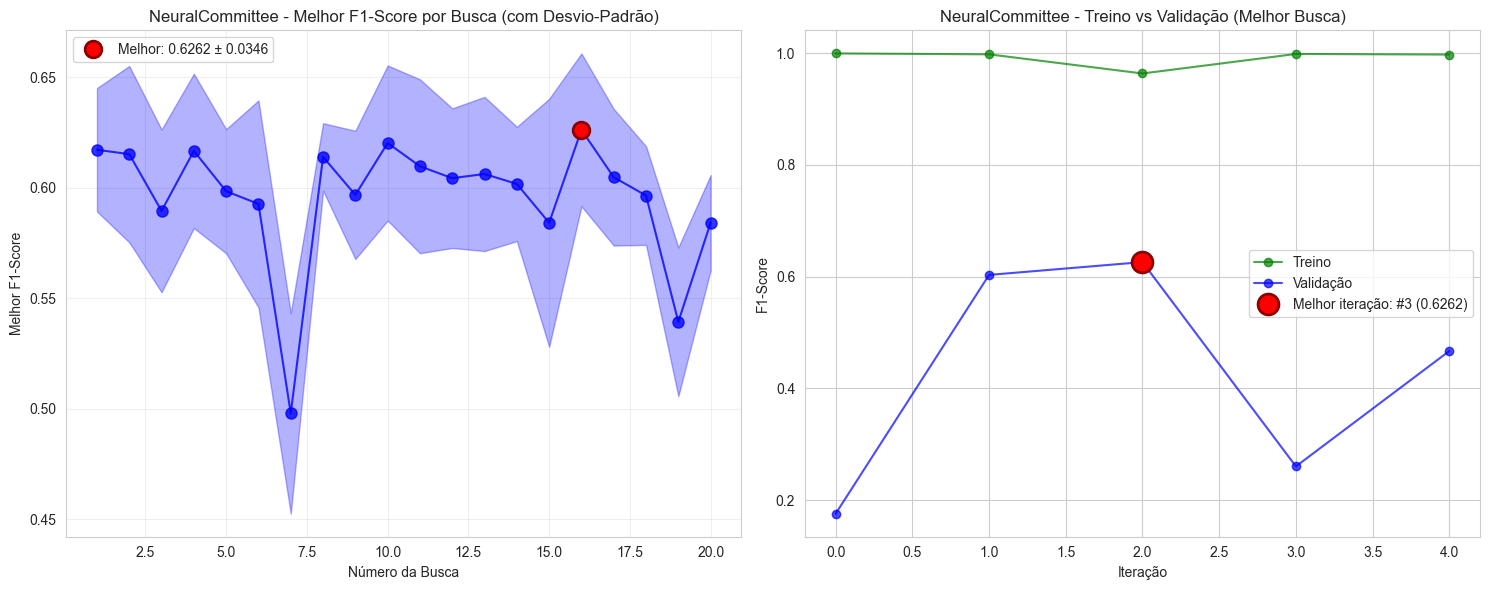

In [9]:
# Registro de Desempenho - plotar evolução da busca
plot_search_history(all_searches, search, MODEL_NAME)

In [10]:
# ======================================================================
# ANÁLISE DAS MELHORES CONFIGURAÇÕES ENCONTRADAS
# ======================================================================

print(f"=== MELHORES CONFIGURAÇÕES ENCONTRADAS POR BUSCA - {MODEL_NAME} ===")

# Extrair os melhores resultados de cada busca
best_configs = []

for i, search_result in enumerate(all_searches):
    config = {
        'Busca': i + 1,
        'F1_Score': search_result['best_score'],
        **search_result['best_params']
    }
    best_configs.append(config)

# Criar DataFrame e exibir top configs
results_df = pd.DataFrame(best_configs)
results_df = results_df.sort_values('F1_Score', ascending=False).round(4)

print(f"\nTop configurações (de {len(results_df)} buscas):")
print(results_df.to_string(index=False))

print(f"\nEstatísticas dos F1-Scores encontrados:")
print(f"  Média: {results_df['F1_Score'].mean():.4f}")
print(f"  Mediana: {results_df['F1_Score'].median():.4f}")
print(f"  Desvio padrão: {results_df['F1_Score'].std():.4f}")
print(f"  Min: {results_df['F1_Score'].min():.4f}")
print(f"  Max: {results_df['F1_Score'].max():.4f}")

=== MELHORES CONFIGURAÇÕES ENCONTRADAS POR BUSCA - NeuralCommittee ===

Top configurações (de 20 buscas):
 Busca  F1_Score mlp1_activation  mlp1_alpha mlp1_hidden_layers mlp1_learning_rate  mlp1_learning_rate_init  mlp1_max_iter mlp1_solver mlp2_activation  mlp2_alpha mlp2_hidden_layers mlp2_learning_rate  mlp2_learning_rate_init  mlp2_max_iter mlp2_solver mlp3_activation  mlp3_alpha mlp3_hidden_layers mlp3_learning_rate  mlp3_learning_rate_init  mlp3_max_iter mlp3_solver
    16    0.6262            relu      0.0113   (1024, 384, 128)           constant                   0.0207            744         sgd            tanh      0.0002     (256, 128, 64)           constant                   0.0019            595         sgd            relu      0.0000      (100, 50, 25)           constant                   0.0339            907        adam
    10    0.6202            relu      0.0001         (768, 256)           adaptive                   0.0012            967        adam            relu  

## 6. Salvar Resultados de Busca

In [11]:

search_df = save_search_results(
    model_name=MODEL_NAME,
    model_search=search,
    model_all_searches=all_searches,
    n_searches=N_SEARCHES,
    n_iter_per_search=N_ITER_PER_SEARCH,
    scoring=SCORING_METRIC,
    cv_folds=DEFAULT_CV_STRATEGY.get_n_splits(),
    top_params_columns=param_distributions.keys(),
    searches_folder=SEARCHES_FOLDER
)

=== SALVANDO RESULTADOS DA BUSCA - NEURALCOMMITTEE ===
  ✅ Todos os Resultados salvos: searches\neuralcommittee_all_searches.csv
  Total de configurações testadas: 100
  ✅ Resumo salvo: searches\neuralcommittee_search_summary.json

--- ESTATÍSTICAS DA BUSCA NEURALCOMMITTEE ---
Melhor F1-Score: 0.6262
Desvio padrão do melhor: 0.0346
F1-Score médio geral: 0.4447
F1-Score mínimo: 0.1280
F1-Score máximo: 0.6262


### 6.2 Carregar Resultado de Busca (Opcional)

In [12]:
loaded_results = load_search_results(MODEL_NAME)

=== CARREGANDO RESULTADOS DE BUSCA - NEURALCOMMITTEE ===
✅ Resultados detalhados carregados: 100 configurações
✅ Resumo carregado: F1-Score = 0.6262


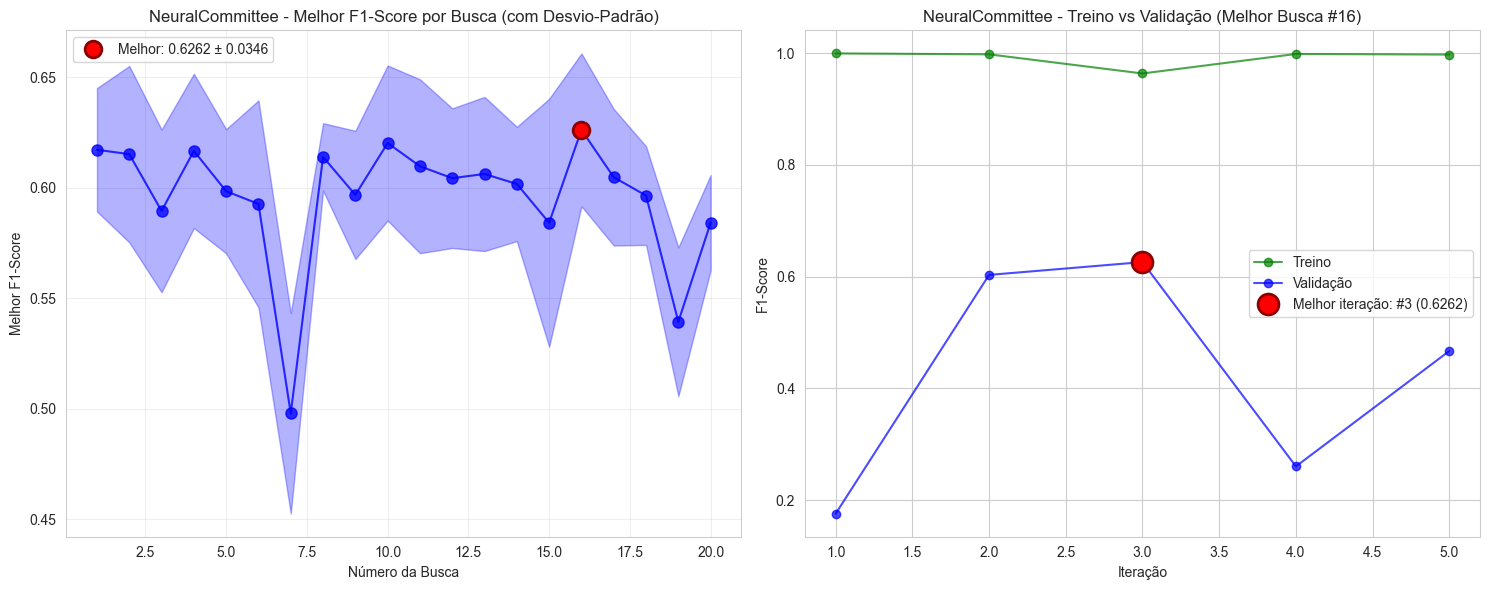

In [13]:
# Plotar a história da busca a partir dos resultados carregados
plot_search_history_from_loaded(loaded_results, MODEL_NAME)

### 6.3 Definir Melhores Params e CV score

In [ ]:
# Definir Melhores Parâmetros para Uso Posterior
if 'loaded_results' in locals():
    best_params = get_best_params_from_saved(MODEL_NAME)
    best_score = loaded_results['summary']['best_overall_score']
    print(f"✅ Usando parâmetros carregados: {best_params}")
    print(f"✅ Melhor F1-Score carregado: {best_score:.4f}")
else:
    best_params = search.best_params_
    best_score = search.best_score_
    print(f"✅ Usando parâmetros da busca atual: {best_params}")
    print(f"✅ Melhor F1-Score da busca atual: {best_score:.4f}")

✅ Usando parâmetros carregados: {'mlp1_activation': 'relu', 'mlp1_alpha': 0.011349847638749523, 'mlp1_hidden_layers': '(1024, 384, 128)', 'mlp1_learning_rate': 'constant', 'mlp1_learning_rate_init': 0.020664303884563313, 'mlp1_max_iter': 744, 'mlp1_solver': 'sgd', 'mlp2_activation': 'tanh', 'mlp2_alpha': 0.0002115262952284861, 'mlp2_hidden_layers': '(256, 128, 64)', 'mlp2_learning_rate': 'constant', 'mlp2_learning_rate_init': 0.0019266567866889665, 'mlp2_max_iter': 595, 'mlp2_solver': 'sgd', 'mlp3_activation': 'relu', 'mlp3_alpha': 1.6264879327210566e-05, 'mlp3_hidden_layers': '(100, 50, 25)', 'mlp3_learning_rate': 'constant', 'mlp3_learning_rate_init': 0.03392978653851999, 'mlp3_max_iter': 907, 'mlp3_solver': 'adam'}
✅ Melhor F1-Score carregado: 0.6262


## 7. Treinar Modelo Final e Salvar

In [ ]:

import ast

clean_params = {}
for k, v in best_params.items():
    if isinstance(v, str) and v.startswith("(") and v.endswith(")"):
        try:
            clean_params[k] = ast.literal_eval(v)
        except:
            clean_params[k] = v
    else:
        clean_params[k] = v

# Treinamento Final com melhores hiperparâmetros


best_model = MODEL_CLASS(random_state=RANDOM_STATE_MODEL, **clean_params)
best_model.fit(X_train_scaled, y_train)
print(f"\nModelo final {MODEL_NAME} treinado com dataset completo: {best_model}")

NeuralNetworkCommittee(mlp1_alpha=0.011349847638749523,
                       mlp1_hidden_layers=(1024, 384, 128),
                       mlp1_learning_rate_init=0.020664303884563313,
                       mlp1_max_iter=744, mlp1_solver='sgd',
                       mlp2_alpha=0.0002115262952284861,
                       mlp2_hidden_layers=(256, 128, 64),
                       mlp2_learning_rate='constant',
                       mlp2_learning_rate_init=0.0019266567866889665,
                       mlp2_max_iter=595, mlp2_solver='sgd',
                       mlp3_activation='relu',
                       mlp3_alpha=1.6264879327210566e-05,
                       mlp3_hidden_layers=(100, 50, 25),
                       mlp3_learning_rate_init=0.03392978653851999,
                       mlp3_max_iter=907, random_state=42)

Modelo final NeuralCommittee treinado com dataset completo: NeuralNetworkCommittee(mlp1_alpha=0.011349847638749523,
                       mlp1_hidden_layers=(1024,

In [26]:

# Save the trained model immediately after training
os.makedirs(MODELS_FOLDER, exist_ok=True)

model_path = os.path.join(MODELS_FOLDER, f'{MODEL_NAME.lower().replace(" ", "_")}_model.joblib')
dump(best_model, model_path)
print(f"✅ Model saved to: {model_path}")

✅ Model saved to: models\neuralcommittee_model.joblib


## 8. Avaliação Final e Salvamento dos Resultados

In [27]:
# Carregar modelo (Opcional)
loaded_model = load(os.path.join(MODELS_FOLDER, f'{MODEL_NAME.lower().replace(" ", "_")}_model.joblib'))

In [28]:
print(f"=== AVALIAÇÃO E SALVAMENTO DOS RESULTADOS - {MODEL_NAME} ===")

# Criar pastas se não existirem
os.makedirs(RESULTS_FOLDER, exist_ok=True)

# Avaliação completa do modelo
print("\nAvaliando performance do modelo...")

# Usar datasets completos para avaliação final
X_train_eval = X_train_scaled
y_train_eval = y_train
X_test_eval = X_test_scaled
y_test_eval = y_test

# Avaliar modelo usando função do módulo
train_metrics, test_metrics, y_test_pred = evaluate_model(
    best_model, X_train_eval, X_test_eval, y_train_eval, y_test_eval, MODEL_NAME
)

=== AVALIAÇÃO E SALVAMENTO DOS RESULTADOS - NeuralCommittee ===

Avaliando performance do modelo...


### 8.1 Classification Report

In [29]:
print(classification_report(y_test_eval, y_test_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.84      0.88      0.86       813
           1       0.88      0.93      0.90      2430
           2       0.88      0.89      0.89      1790
           3       0.83      0.82      0.83      1408
           4       0.90      0.88      0.89      1257
           5       0.86      0.84      0.85      1203
           6       0.83      0.82      0.83       995
           7       0.88      0.86      0.87       912
           8       0.82      0.74      0.78       815
           9       0.83      0.81      0.82       788

    accuracy                           0.86     12411
   macro avg       0.85      0.85      0.85     12411
weighted avg       0.86      0.86      0.86     12411



### 8.2 Visualize Confusion Matrix

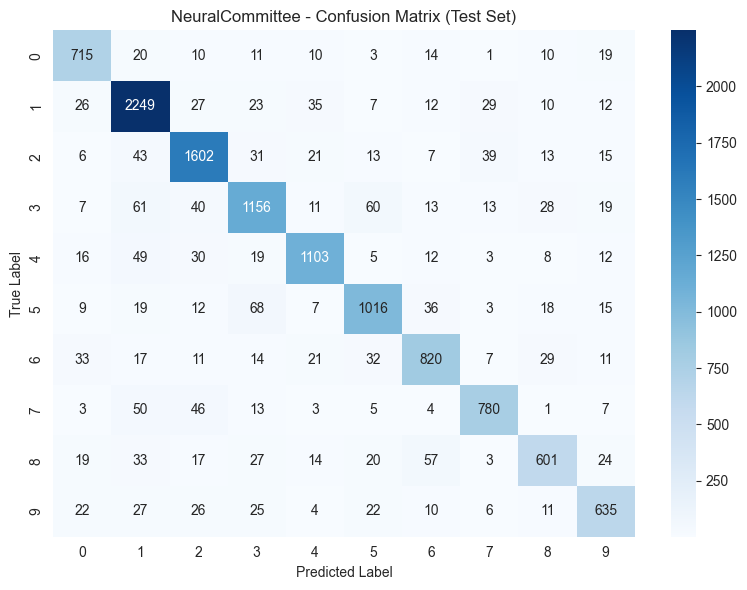

In [30]:
# Plot confusion matrix
cm = confusion_matrix(y_test_eval, y_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.title(f'{MODEL_NAME} - Confusion Matrix (Test Set)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

### 8.3 Save Final Results

In [31]:
# Salvar resultados finais usando função do módulo
model_final_results = save_final_results(
    model_name=MODEL_NAME,
    best_params=best_params,
    best_score=best_score,
    train_metrics=train_metrics,
    test_metrics=test_metrics,
    y_pred=y_test_pred,
    y_test=y_test_eval,
    X_train_scaled=X_train_eval,
    X_test_scaled=X_test_eval,
    results_folder=RESULTS_FOLDER
)

# Mostrar resumo final
print(f"\n--- RESUMO FINAL {MODEL_NAME} ---")
print(f"F1-Score CV: {model_final_results['best_cv_score']:.4f}")
print(f"F1-Score Teste: {test_metrics['f1']:.4f}")
print(f"Acurácia Teste: {test_metrics['accuracy']:.4f}")
print(f"Precisão Teste: {test_metrics['precision']:.4f}")
print(f"Recall Teste: {test_metrics['recall']:.4f}")
print(f"G-Mean Teste: {test_metrics['gmean']:.4f}")

print(f"Resultados salvos em: {RESULTS_FOLDER}/")
print(f"\nAvaliação do {MODEL_NAME} concluída com sucesso!")

✅ Resultados NeuralCommittee salvos em: results\neuralcommittee_results.json

--- RESUMO FINAL NeuralCommittee ---
F1-Score CV: 0.6262
F1-Score Teste: 0.8501
Acurácia Teste: 0.8603
Precisão Teste: 0.8546
Recall Teste: 0.8466
G-Mean Teste: 0.8450
Resultados salvos em: results/

Avaliação do NeuralCommittee concluída com sucesso!
